In [9]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt 
from sklearn.preprocessing import LabelEncoder 
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression 

In [ ]:
data=pd.read_csv(r"datasets\heart.csv")

In [11]:
#Statistical (EDA)

In [12]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [14]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [15]:
data.shape

(1025, 14)

In [16]:
data["target"].unique()

array([0, 1])

In [17]:
data["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

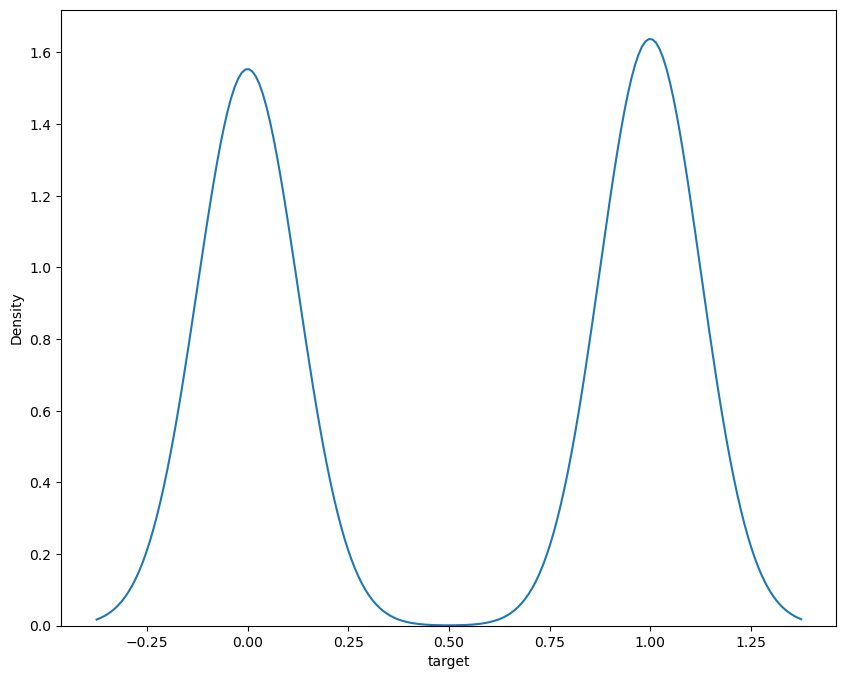

In [18]:
#visuals
plt.figure(figsize=(10,8))
sns.kdeplot(data["target"])
plt.show()

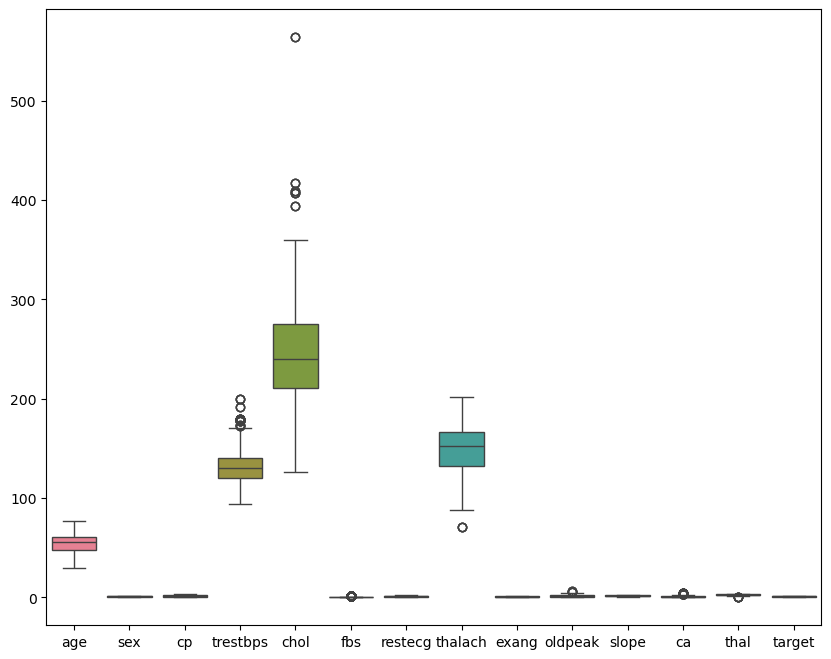

In [19]:
#visuals
plt.figure(figsize=(10,8))
sns.boxplot(data)
plt.show()

In [20]:
#removing outliers

In [21]:
import numpy as np
import seaborn as sns
def roy(data, x):
    q1 = np.quantile(data[x], 0.25)
    q3 = np.quantile(data[x], 0.75)
    iqr = q3 - q1
    
    lowest_value = q1 - 1.5 * iqr
    highest_value = q3 + 1.5 * iqr
    
    filtered_data = data[(data[x] > lowest_value) & (data[x] < highest_value)]
    
    print("Removing outliers completed...")
    sns.boxplot(data[x])
    return filtered_data

Removing outliers completed...


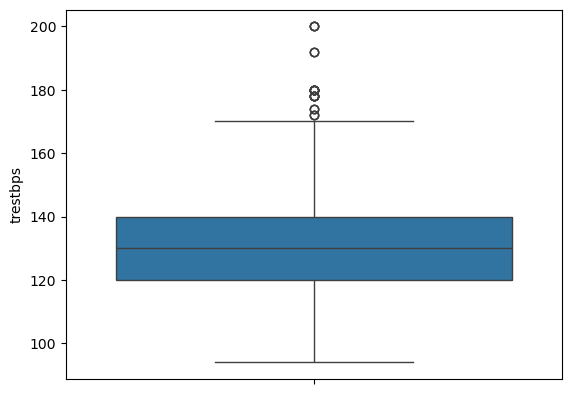

In [22]:
data=roy(data,"trestbps")

Removing outliers completed...


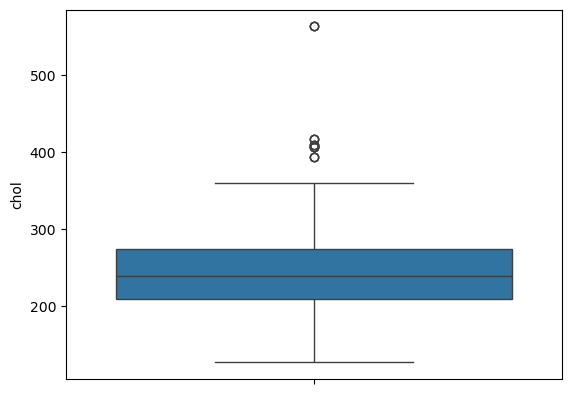

In [23]:
data=roy(data,"chol")

Removing outliers completed...


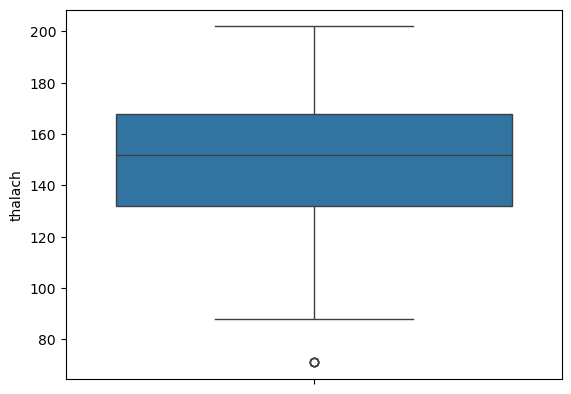

In [24]:
data=roy(data,"thalach")

<Axes: >

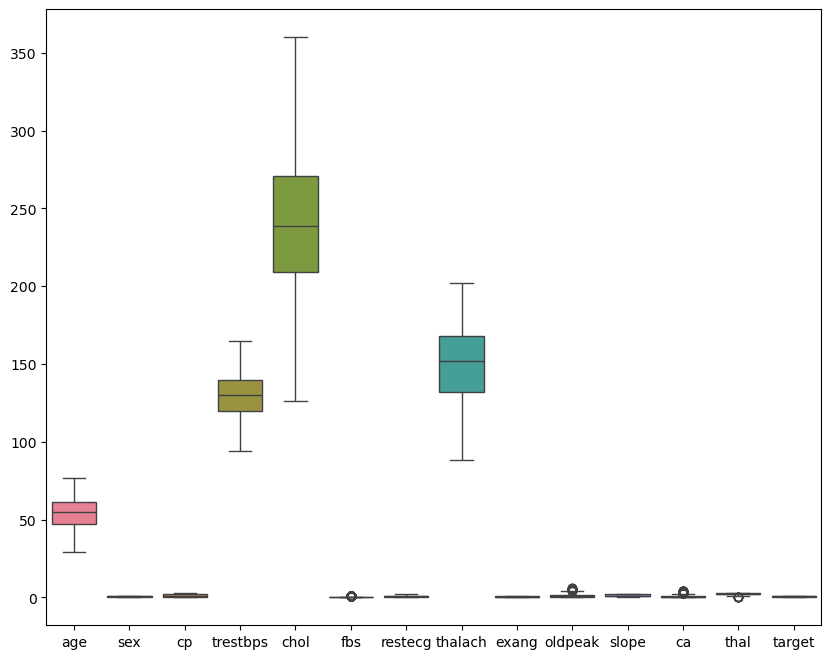

In [25]:
plt.figure(figsize=(10,8))
sns.boxplot(data)

In [26]:
#Encoding
#We already have everything in numaric we can skip this step
#data=LabelEncoder().fit_transform(data) if we needed
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 960 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       960 non-null    int64  
 1   sex       960 non-null    int64  
 2   cp        960 non-null    int64  
 3   trestbps  960 non-null    int64  
 4   chol      960 non-null    int64  
 5   fbs       960 non-null    int64  
 6   restecg   960 non-null    int64  
 7   thalach   960 non-null    int64  
 8   exang     960 non-null    int64  
 9   oldpeak   960 non-null    float64
 10  slope     960 non-null    int64  
 11  ca        960 non-null    int64  
 12  thal      960 non-null    int64  
 13  target    960 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 112.5 KB


In [27]:
#Train test split
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [28]:
x=data.drop("target",axis=1)
x

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2


In [29]:
y=data["target"]
y

0       0
1       0
2       0
3       0
4       0
       ..
1020    1
1021    0
1022    0
1023    1
1024    0
Name: target, Length: 960, dtype: int64

In [30]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [31]:
x.shape

(960, 13)

In [32]:
x_train.shape

(768, 13)

In [33]:
x_test.shape

(192, 13)

In [34]:
y.shape

(960,)

In [35]:
y_train.shape

(768,)

In [36]:
y_test.shape

(192,)

In [37]:
#Model Development

In [38]:
model=LogisticRegression()
model.fit(x_train,y_train)

c:\Users\NSTI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [39]:
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]  # probability of class 1

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8697916666666666


In [40]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [41]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [42]:
model.predict([[70,1,0,145,174,0,1,125,1,2.6,0,0,3]])

c:\Users\NSTI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

In [43]:
model.predict([[50,0,0,110,254,0,0,159,0,0.0,2,0,2]])

c:\Users\NSTI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([1])

In [44]:
from sklearn.metrics import precision_score
precision = precision_score(y_test, y_pred, average='weighted')
precision

0.8786744800418207

In [45]:
from sklearn.metrics import recall_score
recall = recall_score(y_test, y_pred, average='weighted')
recall


0.8697916666666666

In [46]:
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred, average='weighted')
f1


0.868775055018309

In [47]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm


array([[74, 20],
       [ 5, 93]])

In [48]:
from sklearn.metrics import classification_report
report = classification_report(y_test, y_pred)
report

'              precision    recall  f1-score   support\n\n           0       0.94      0.79      0.86        94\n           1       0.82      0.95      0.88        98\n\n    accuracy                           0.87       192\n   macro avg       0.88      0.87      0.87       192\nweighted avg       0.88      0.87      0.87       192\n'

In [49]:
print(report)

              precision    recall  f1-score   support

           0       0.94      0.79      0.86        94
           1       0.82      0.95      0.88        98

    accuracy                           0.87       192
   macro avg       0.88      0.87      0.87       192
weighted avg       0.88      0.87      0.87       192



In [50]:
data.to_csv("heart_final.csv",index=False)

In [53]:
import pandas as pd
import gradio as gr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
data = pd.read_csv(r"C:\Users\NSTI\OneDrive\Documents\Data Science\Machine Learning\model\heart_final.csv")

# Split features and target
x = data.drop("target", axis=1)
y = data["target"]

# Train test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)

# Evaluate
y_pred = model.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

# Prediction function for Gradio
def predict_heart(age, sex, cp, trestbps, chol, fbs, restecg,
                  thalach, exang, oldpeak, slope, ca, thal):

    input_data = [[age, sex, cp, trestbps, chol, fbs, restecg,
                   thalach, exang, oldpeak, slope, ca, thal]]

    prediction = model.predict(input_data)[0]
    probability = model.predict_proba(input_data)[0][1]

    if prediction == 1:
        result = "Heart Disease Detected"
    else:
        result = "No Heart Disease"

    return f"{result} (Risk Probability: {probability:.2f})"


# Gradio Interface
interface = gr.Interface(
    fn=predict_heart,
    inputs=[
        gr.Number(label="Age"),
        gr.Radio([0,1], label="Sex (0=Female,1=Male)"),
        gr.Number(label="Chest Pain Type (cp)"),
        gr.Number(label="Resting Blood Pressure"),
        gr.Number(label="Cholesterol"),
        gr.Radio([0,1], label="Fasting Blood Sugar >120"),
        gr.Number(label="Rest ECG"),
        gr.Number(label="Max Heart Rate (thalach)"),
        gr.Radio([0,1], label="Exercise Induced Angina"),
        gr.Number(label="Oldpeak"),
        gr.Number(label="Slope"),
        gr.Number(label="CA"),
        gr.Number(label="Thal")
    ],
    outputs="text",
    title="Heart Disease Prediction",
    description="Enter patient medical values to predict heart disease risk."
)

# Launch app
interface.launch()



c:\Users\NSTI\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Accuracy: 0.8697916666666666
* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


c:\Users\NSTI\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
Traceback (most recent call last):
  File "c:\Users\NSTI\anaconda3\Lib\site-packages\gradio\queueing.py", line 766, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
    )
    ^
  File "c:\Users\NSTI\anaconda3\Lib\site-packages\gradio\route_utils.py", line 355, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<11 lines>...
    )
    ^
  File "c:\Users\NSTI\anaconda3\Lib\site-packages\gradio\blocks.py", line 2158, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
    ...<8 lines>...
    )
    ^
  File "c:\Users\NSTI\anaconda3\Lib\site-packages\gradio\blocks.py", line 1634, in call_function